# 🔦 A Quick Look Ahead: Other Flavours of Regression

You have now built a regression model. One input (carbon content), one output (hardness), one line. 

Real materials problems are rarely that clean.

This page is a **short preview** of four regression ideas - still built on the same foundations but slightly adjusted for different scenarios. Think of it as a movie trailer 🎥. You will not understand every scene yet, and that is fine. It's just a taste to get you familiarized.

```{tip}
Nothing here needs to be memorised. Read it once, look at the pictures, and move on.
```

```{note}
All datasets in this notebook are **synthetic**. They were built to make each idea visible. Real data is messier.
```

## Words to listen for

```{dropdown} Vocabulary from this preview
- **Multivariate** - more than one input variable
- **Coefficient** - the weight a model gives to a feature.
- **Regularisation** - adding a penalty to stop a model over-fitting
- **Shrinkage** - pulling coefficients towards zero
- **Penalty strength (alpha)** - the dial that controls how hard we shrink
- **Feature selection** - deciding which inputs are actually worth keeping
- **Sparse model** - a model where most coefficients are zero
- **Classification** - predicting a category instead of a number
- **Probability** - a number between 0 and 1 describing how likely something is
```

## Setting up

We build a small fake dataset of steel samples. Each sample has a carbon content, a grain size, and a cooling rate. From these we make a hardness value.

You do not need to follow the code. Look at the plots.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

rng = np.random.default_rng(0)   # fixed seed, so everyone sees the same picture
n = 80

carbon   = rng.uniform(0.1, 1.0, n)    # weight %
grain    = rng.uniform(5, 60, n)       # micrometres
cooling  = rng.uniform(1, 50, n)       # degrees C per second

hardness = 180 + 260*carbon - 2.2*grain + 0.9*cooling + rng.normal(0, 18, n)

print("We have", n, "fake steel samples.")
print("Hardness runs from", round(hardness.min()), "to", round(hardness.max()), "HV.")

We have 80 fake steel samples.
Hardness runs from 92 to 471 HV.


## 1. Multivariate regression: more than one input 

So far: one property input, one number output.

But hardness probably does not depend on carbon alone. The grain size matters and so does the cooling rate. **Multivariate regression** simply means we feed in more than one input feature.
On the left, carbon only. On the right, all three inputs.

Let us look at what that gives us. 

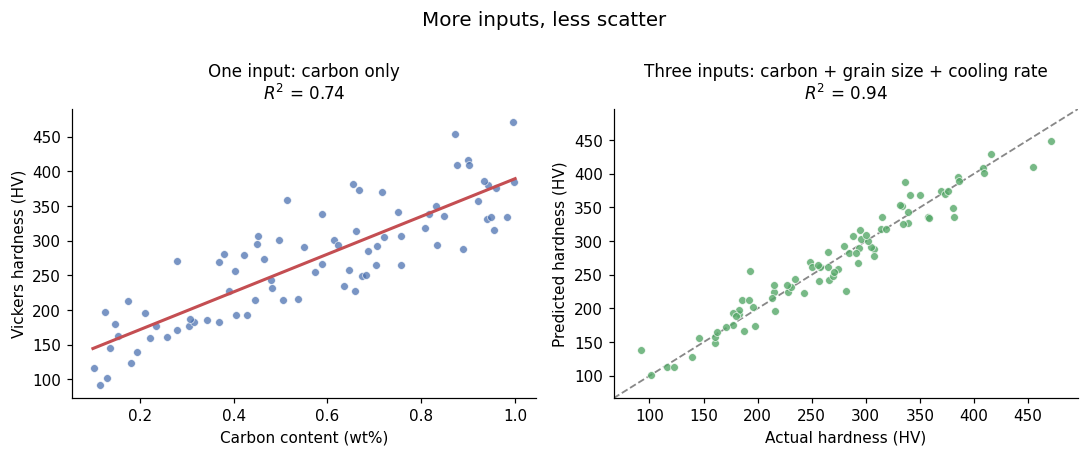

In [4]:
model_a = LinearRegression().fit(carbon.reshape(-1, 1), hardness)
r2_a = r2_score(hardness, model_a.predict(carbon.reshape(-1, 1)))

X_all = np.c_[carbon, grain, cooling]
model_b = LinearRegression().fit(X_all, hardness)
pred_b = model_b.predict(X_all)
r2_b = r2_score(hardness, pred_b)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.1))

ax[0].scatter(carbon, hardness, s=26, color="#4C72B0", alpha=.75, edgecolor="w", lw=.5)
xs = np.linspace(0.1, 1.0, 50)
ax[0].plot(xs, model_a.predict(xs.reshape(-1, 1)), color="#C44E52", lw=2)
ax[0].set_xlabel("Carbon content (wt%)")
ax[0].set_ylabel("Vickers hardness (HV)")
ax[0].set_title(f"One input: carbon only\n$R^2$ = {r2_a:.2f}", fontsize=11)

lim = [hardness.min() - 25, hardness.max() + 25]
ax[1].plot(lim, lim, "--", color="#888", lw=1.2, zorder=1)
ax[1].scatter(hardness, pred_b, s=26, color="#55A868", alpha=.8,
              edgecolor="w", lw=.5, zorder=2)
ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel("Actual hardness (HV)")
ax[1].set_ylabel("Predicted hardness (HV)")
ax[1].set_title(f"Three inputs: carbon + grain size + cooling rate\n$R^2$ = {r2_b:.2f}",
                fontsize=11)

fig.suptitle("More inputs, less scatter", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

The scatter tightens up. Adding the two extra inputs took us from $R^2 \approx 0.74$ to $R^2 \approx 0.94$.

```{dropdown} Something to think about 🤔
If two of your inputs tell almost the same story (say, two elemental properties that always move together, e.g. atomic number and atomic weight), does the model need to trust both of them equally? Hold onto that question. It is exactly the problem the next method was invented to solve.
```

## 2. Ridge regression: a leash on the coefficients ➰

More inputs also bring a new risk. The model can become **too confident**.

It might give one feature a huge weight just because that feature happened to line up nicely with a small dataset. That huge weight will not survive with new data.

**Ridge regression** adds a rule: *big coefficients get punished.* The model may still use every feature, but it cannot let any single one have the loudest say. So, coefficients get pulled gently towards zero.

Think of it as a leash🐕‍🦺 that keeps it in control.

## 3. Lasso regression: permission to say "zero"

Ridge shrinks coefficients, but it almost never makes them *exactly* zero.

**Lasso** uses a slightly different penalty, and that small change has a big effect: Lasso *can* push a coefficient all the way to zero. When it does, that feature is effectively deleted from the model.

E.g.
If our regression equation is $y=a+bx+cx^2+dx^3$, and lasso decides that the coefficient $d$ is not useful, then it can $d \rightarrow 0$ thereby reducing the regression equation to $y=a+bx+cx^2$

So Lasso does two jobs at once. It fits a model, and it tells you which inputs were worth having.

Below we build a messier dataset. Five features are real. Three are pure nonsense that is in the dataset: furnace ID, batch number, and room humidity. Watch what each method does with the nonsense. Look at the graphs of how the coefficient values change as the penalty strength increases.

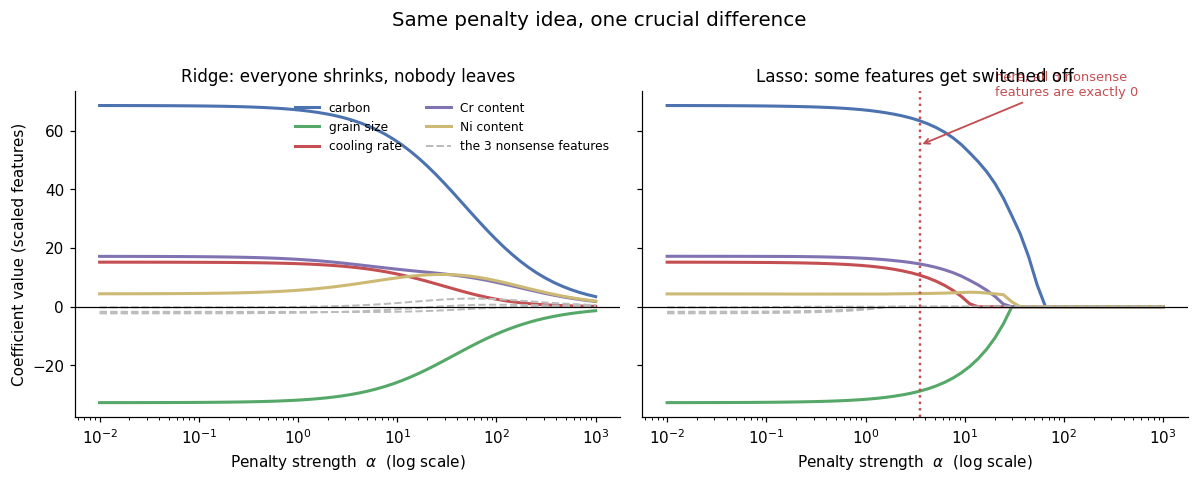

In [5]:
rng = np.random.default_rng(0)
m = 60

names = ["carbon", "grain size", "cooling rate", "Cr content", "Ni content",
         "furnace ID", "batch number", "room humidity"]

c2   = rng.uniform(0.1, 1.0, m)
g2   = rng.uniform(5, 60, m)
cl2  = rng.uniform(1, 50, m)
cr2  = rng.uniform(0, 18, m)
ni2  = 0.6*cr2 + rng.normal(0, 1.5, m)          # deliberately tied to Cr
junk = [rng.uniform(0, 10, m) for _ in range(3)] # meaningless columns

X2 = np.c_[c2, g2, cl2, cr2, ni2, junk[0], junk[1], junk[2]]
y2 = 180 + 260*c2 - 2.2*g2 + 0.9*cl2 + 4.0*cr2 + rng.normal(0, 15, m)

X2s = StandardScaler().fit_transform(X2)         # scaling matters here!
alphas = np.logspace(-2, 3, 60)

ridge_path = np.array([Ridge(alpha=a).fit(X2s, y2).coef_ for a in alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=20000).fit(X2s, y2).coef_ for a in alphas])

real_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)

for k, (path, title) in enumerate([(ridge_path, "Ridge: everyone shrinks, nobody leaves"),
                                   (lasso_path, "Lasso: some features get switched off")]):
    for i in range(8):
        if i < 5:
            ax[k].plot(alphas, path[:, i], color=real_colors[i], lw=2,
                       label=names[i] if k == 0 else None)
        else:
            ax[k].plot(alphas, path[:, i], color="#bbb", lw=1.3, ls="--",
                       label="the 3 nonsense features" if (k == 0 and i == 5) else None)
    ax[k].set_xscale("log")
    ax[k].axhline(0, color="k", lw=.8)
    ax[k].set_xlabel("Penalty strength  $\\alpha$  (log scale)")
    ax[k].set_title(title, fontsize=11)

ax[0].set_ylabel("Coefficient value (scaled features)")
ax[1].axvline(3.5, color="#C44E52", ls=":", lw=1.6)
ax[1].annotate("here, all 3 nonsense\nfeatures are exactly 0", xy=(3.5, 55),
               xytext=(20, 72), fontsize=8.5, color="#C44E52",
               arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.2))
ax[0].legend(fontsize=8, frameon=False, ncol=2, loc="upper right")

fig.suptitle("Same penalty idea, one crucial difference", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

Look at the two panels again.

- **Left (Ridge):** every line bends towards zero, but none of them ever *touch* it. All eight features stay in the model, nonsense included.
- **Right (Lasso):** the grey dashed lines hit zero and stay there. The nonsense features are gone.

Let us ask Lasso directly which features it kept.

In [6]:
for alpha in [0.01, 0.5, 3.5, 25.0]:
    coefs = Lasso(alpha=alpha, max_iter=20000).fit(X2s, y2).coef_
    kept = [names[i] for i in range(8) if coefs[i] != 0]
    print(f"alpha = {alpha:6.2f}  ->  {len(kept)} features kept: {kept}")

alpha =   0.01  ->  8 features kept: ['carbon', 'grain size', 'cooling rate', 'Cr content', 'Ni content', 'furnace ID', 'batch number', 'room humidity']
alpha =   0.50  ->  7 features kept: ['carbon', 'grain size', 'cooling rate', 'Cr content', 'Ni content', 'batch number', 'room humidity']
alpha =   3.50  ->  5 features kept: ['carbon', 'grain size', 'cooling rate', 'Cr content', 'Ni content']
alpha =  25.00  ->  4 features kept: ['carbon', 'grain size', 'Cr content', 'Ni content']


At `alpha = 3.5`, Lasso has quietly thrown away exactly the three columns we invented, and kept the five that actually build the hardness. Nobody told it which was which.

```{dropdown} Something to think about
Would you rather have a model that uses all 8 features and is slightly more accurate, or one that uses 5 features, is almost as accurate, and hands you a list of what actually matters?

There is no universally right answer. That is the interesting part.
```

```{note}
Later we will meet **ElasticNet**, which mixes the Ridge and the Lasso penalty together. It tries to get the best of both. It also brings its own trade-offs. That is a story for another lecture.
```

## 4. Logistic regression: a badly named method

Here is a fun one. Despite the name, **logistic regression does not predict numbers. It predicts categories.**

Will this alloy corrode? Yes or no. Is this material a metal, a ceramic, a polymer, or a semiconductor?

Why not just use ordinary regression and round the answer? Let us try it and see what breaks.

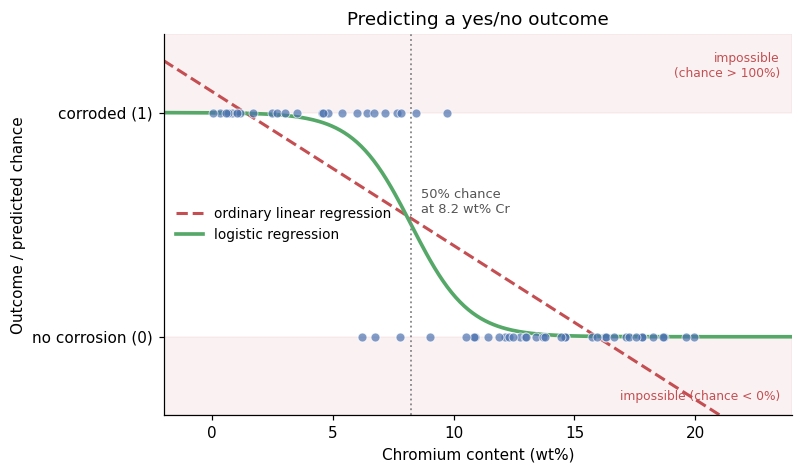

Linear regression predicts a chance as low as -0.55
...and as high as 1.23


In [7]:
rng = np.random.default_rng(0)
k = 60

chromium = rng.uniform(0, 20, k)                    # wt% Cr
true_p   = 1 / (1 + np.exp(0.75 * (chromium - 10))) # more Cr, less corrosion
corroded = (rng.random(k) < true_p).astype(int)     # 1 = corroded, 0 = fine

lin_fit = LinearRegression().fit(chromium.reshape(-1, 1), corroded)
log_fit = LogisticRegression().fit(chromium.reshape(-1, 1), corroded)

grid = np.linspace(-2, 24, 300).reshape(-1, 1)
crossover = float(-log_fit.intercept_[0] / log_fit.coef_[0][0])

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.axhspan(1, 1.35, color="#C44E52", alpha=.07)
ax.axhspan(-0.35, 0, color="#C44E52", alpha=.07)
ax.text(23.5, 1.16, "impossible\n(chance > 100%)", fontsize=8, color="#C44E52", ha="right")
ax.text(23.5, -0.28, "impossible (chance < 0%)", fontsize=8, color="#C44E52", ha="right")

ax.scatter(chromium, corroded, s=34, color="#4C72B0", alpha=.7,
           edgecolor="w", lw=.6, zorder=3)
ax.plot(grid, lin_fit.predict(grid), color="#C44E52", lw=2, ls="--",
        label="ordinary linear regression")
ax.plot(grid, log_fit.predict_proba(grid)[:, 1], color="#55A868", lw=2.4,
        label="logistic regression")
ax.axvline(crossover, color="#888", ls=":", lw=1.2)
ax.text(crossover + .4, .55, f"50% chance\nat {crossover:.1f} wt% Cr",
        fontsize=8.5, color="#555")

ax.set_xlim(-2, 24); ax.set_ylim(-0.35, 1.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(["no corrosion (0)", "corroded (1)"])
ax.set_xlabel("Chromium content (wt%)")
ax.set_ylabel("Outcome / predicted chance")
ax.set_title("Predicting a yes/no outcome", fontsize=12)
ax.legend(fontsize=9, frameon=False, loc="center left")

fig.tight_layout()
plt.show()

print(f"Linear regression predicts a chance as low as {lin_fit.predict(grid).min():.2f}")
print(f"...and as high as {lin_fit.predict(grid).max():.2f}")

Look at the red dashed line. It keeps going. At high chromium it predicts a **negative** chance of corrosion. At low chromium it predicts a chance **above 100%**. Neither of those means anything.

The green line is logistic regression. It bends, flattens, and stays politely between 0 and 1. It also gives us something useful: below about 8 wt% chromium, corrosion becomes more likely than not.

```{note}
Whoever named this method did not prioritise clarity. The word "regression" is a historical accident. Although it is called 'regression' it is more of a 'classification' algorithm.
```

## All four, at a glance

| Method | What is new | Why you would care |
|---|---|---|
| **Multivariate** regression | More than one input | Real properties depend on more than one thing |
| **Ridge** | Punishes large coefficients | Stops the model over-trusting any single feature |
| **Lasso** | Can set coefficients to exactly zero | Also acts as a feature-selection tool |
| **Logistic** | Predicts categories, not numbers | Turns regression machinery into a classifier |

The first three are still predicting a number. Only the last one changes the kind of question being asked.

## One last thought

Ridge and Lasso both make the model fit the training data **slightly worse** on purpose.

That is strange. Why would you ever choose a worse fit? 🤔 

Sit with that question. It is one of the most important ideas in this whole course, and we will come back to it properly when Ridge, Lasso, and ElasticNet get their own lecture.